# Dataset Temporal Analysis
The question we want to answer here is:  
- **“On what time scale can we meaningfully correlate measurements with spatially adjacent industrial sites and emission sources?”**

    Grouping per year

    Measurement count per year as distinct columns

    heatmap: mearumements per year
  

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pfas_trace.config import DATASET_FILE

In [2]:
df = pd.read_parquet(DATASET_FILE).query('country=="France"')

## Just how extensive is the time coverage, anyway?

In [3]:
df.category.unique()

<ArrowStringArray>
['Known PFAS user', 'Presumptive', 'Measurement', 'PFAS production facility']
Length: 4, dtype: str

We do have only 25 Known-PFAS-User und 4 PFAS-production-facilities in france. And these records do not contain any pfas-values.

In [4]:
df_sources = (
    df[
        df["category"].isin([
            "Known PFAS user",
            "PFAS production facility",
        ])
    ]
    .groupby(["category", "name"])
    .agg(
        n_records=("name", "size"),
        n_locations=(
            "lat",
            lambda x: x.astype(str).str.cat(
                df.loc[x.index, "lon"].astype(str),
                sep=","
            ).nunique()
        ),
        n_pfas_sum=("pfas_sum", "count"),
        n_pfas_values=(
            "pfas_values",
            lambda x: x.map(
                lambda value: len(ast.literal_eval(value))
                if isinstance(value, str)
                else 0
            ).sum()
        ),
    )
    .reset_index()
    .sort_values(
        ["category", "n_locations"],
        ascending=[True, False]
    )
)

df_sources

,category,name,n_records,n_locations,n_pfas_sum,n_pfas_values
9,Known PFAS user,Fluorotechnique,2,2,0,0
11,Known PFAS user,Freudenberg,2,2,0,0
0,Known PFAS user,3P Performance Plastics Products,1,1,0,0
1,Known PFAS user,Aberflon,1,1,0,0
2,Known PFAS user,Approflon,1,1,0,0
3,Known PFAS user,BASF Agri Solutions,1,1,0,0
4,Known PFAS user,BioEx,1,1,0,0
5,Known PFAS user,C2M Aurochs Industrie,1,1,0,0
6,Known PFAS user,DEMGY SPN,1,1,0,0
7,Known PFAS user,Eau et Feu,1,1,0,0


### Prepare Temporal Data

In [9]:
df_measurements = df[
    df["category"] == "Measurement"
]
df_measurements["date"] = pd.to_datetime(df_measurements["date"], errors="coerce")
df_measurements["year"] = df_measurements["date"].dt.year

# Location identifier
location_columns = ["lat", "lon"]

# Measurements per year
measurements_per_year = (
    df_measurements.dropna(subset=["year"])
    .groupby("year")
    .size()
)

# Distinct locations per year
locations_per_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby("year")[location_columns]
    .apply(lambda x: x.drop_duplicates().shape[0])
)

# Number of years measured per location
years_per_location = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby(location_columns)["year"]
    .nunique()
)

# Measurements per location and year
measurements_location_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby([*location_columns, "year"])
    .size()
    .rename("measurement_count")
    .reset_index()
)

measurement_heatmap = (
    measurements_location_year
    .pivot(
        index=location_columns,
        columns="year",
        values="measurement_count",
    )
    .fillna(0)
)

### Plot Temporal Data

Text(0, 0.5, 'Number of locations')

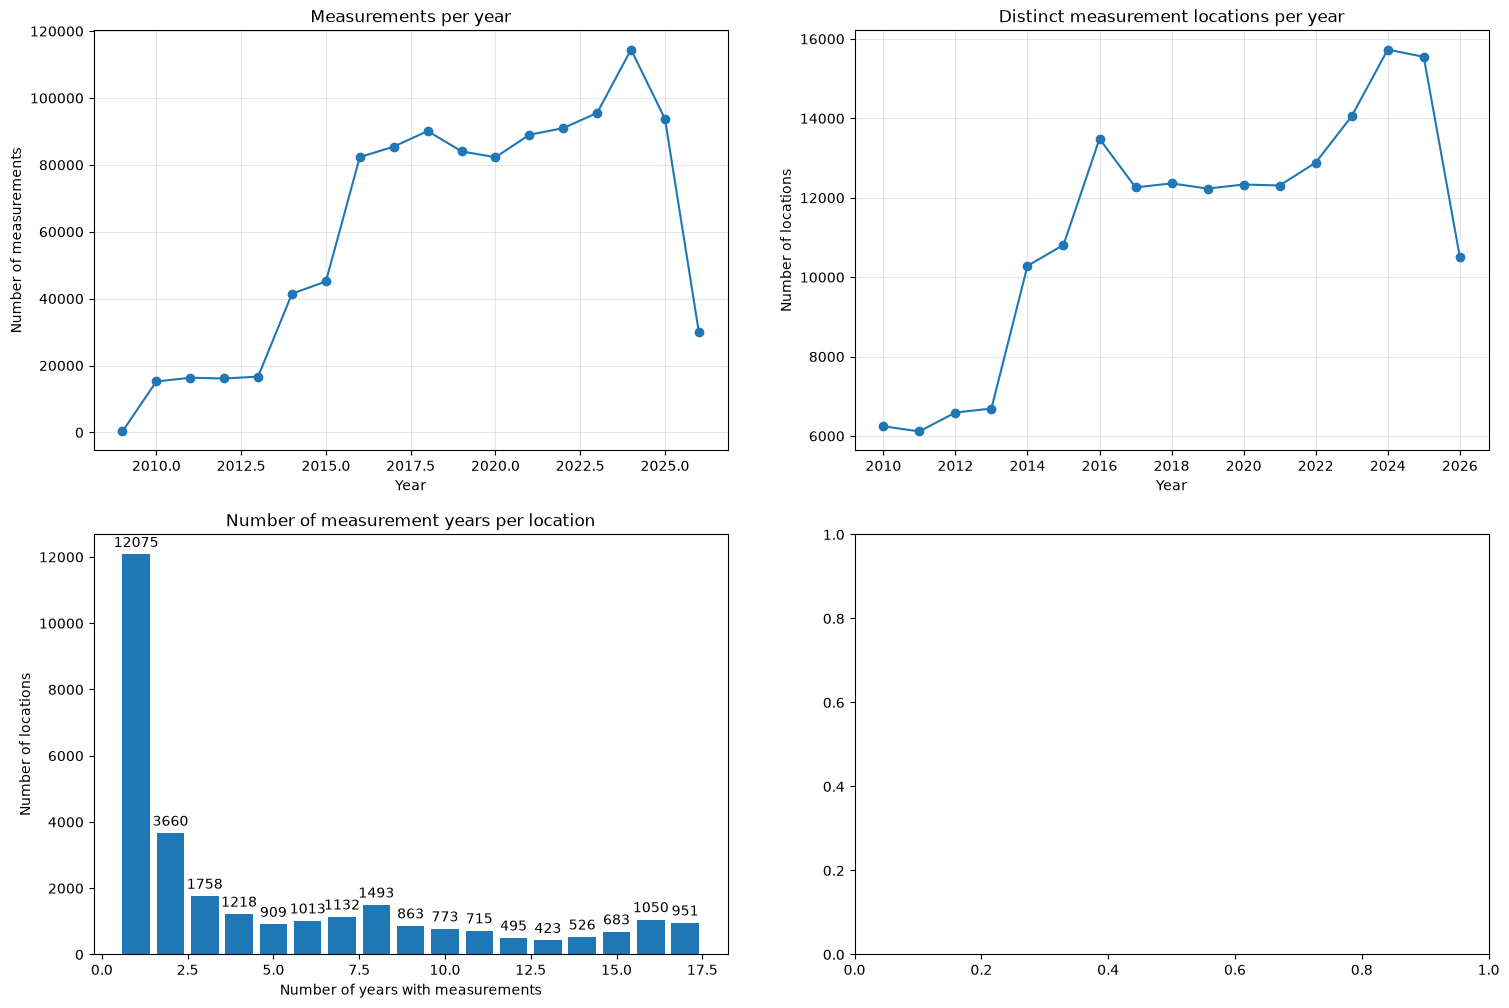

In [21]:

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
)

# 1. Measurements per year
axes[0, 0].plot(
    measurements_per_year.index,
    measurements_per_year.values,
    marker="o",
)

axes[0, 0].set_title("Measurements per year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Number of measurements")
axes[0, 0].grid(True, alpha=0.3)


# 2. Distinct locations per year
axes[0, 1].plot(
    locations_per_year.index,
    locations_per_year.values,
    marker="o",
)

axes[0, 1].set_title("Distinct measurement locations per year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of locations")
axes[0, 1].grid(True, alpha=0.3)


# 3. Distribution of years measured per location
location_counts = years_per_location.value_counts().sort_index()

axes[1, 0].bar(
    location_counts.index,
    location_counts.values,
    width=0.8,
)

axes[1, 0].bar_label(
    axes[1, 0].containers[0],
    fmt="%d",
    padding=3,
)

axes[1, 0].set_title(
    "Number of measurement years per location"
)
axes[1, 0].set_xlabel("Number of years with measurements")
axes[1, 0].set_ylabel("Number of locations")

There are definitely a lot different locations measured over a long period since 16 years.

In [28]:
years_per_location.sort_values(ascending=False).head(50)

lat        lon        city                    
48.982550   0.424446  La Folletière-Abenon        17
47.951029   3.441254  Champlay                    17
45.543688   3.529875  Échandelys                  17
46.310238   4.886128  Replonges                   17
47.975066   4.674551  Riel-les-Eaux               17
48.979828   1.672697  Buchelay                    17
48.980710   5.126557  Èvres                       17
48.719895   4.029380  Euvy                        17
43.667596   4.061763  Valergues                   17
48.705811  -0.324293  Saint-Hilaire-de-Briouze    17
48.712363   3.488134  Courgivaux                  17
49.238212  -1.314064  Terre-et-Marais             17
49.238351  -0.731394  Arganchy                    17
47.331160   6.300403  Fourbanne                   17
43.677654   4.431216  Saint-Gilles                17
43.693291   4.276099  Vauvert                     17
49.252566  -1.504469  Vesly                       17
43.291316   5.862809  Signes                      17

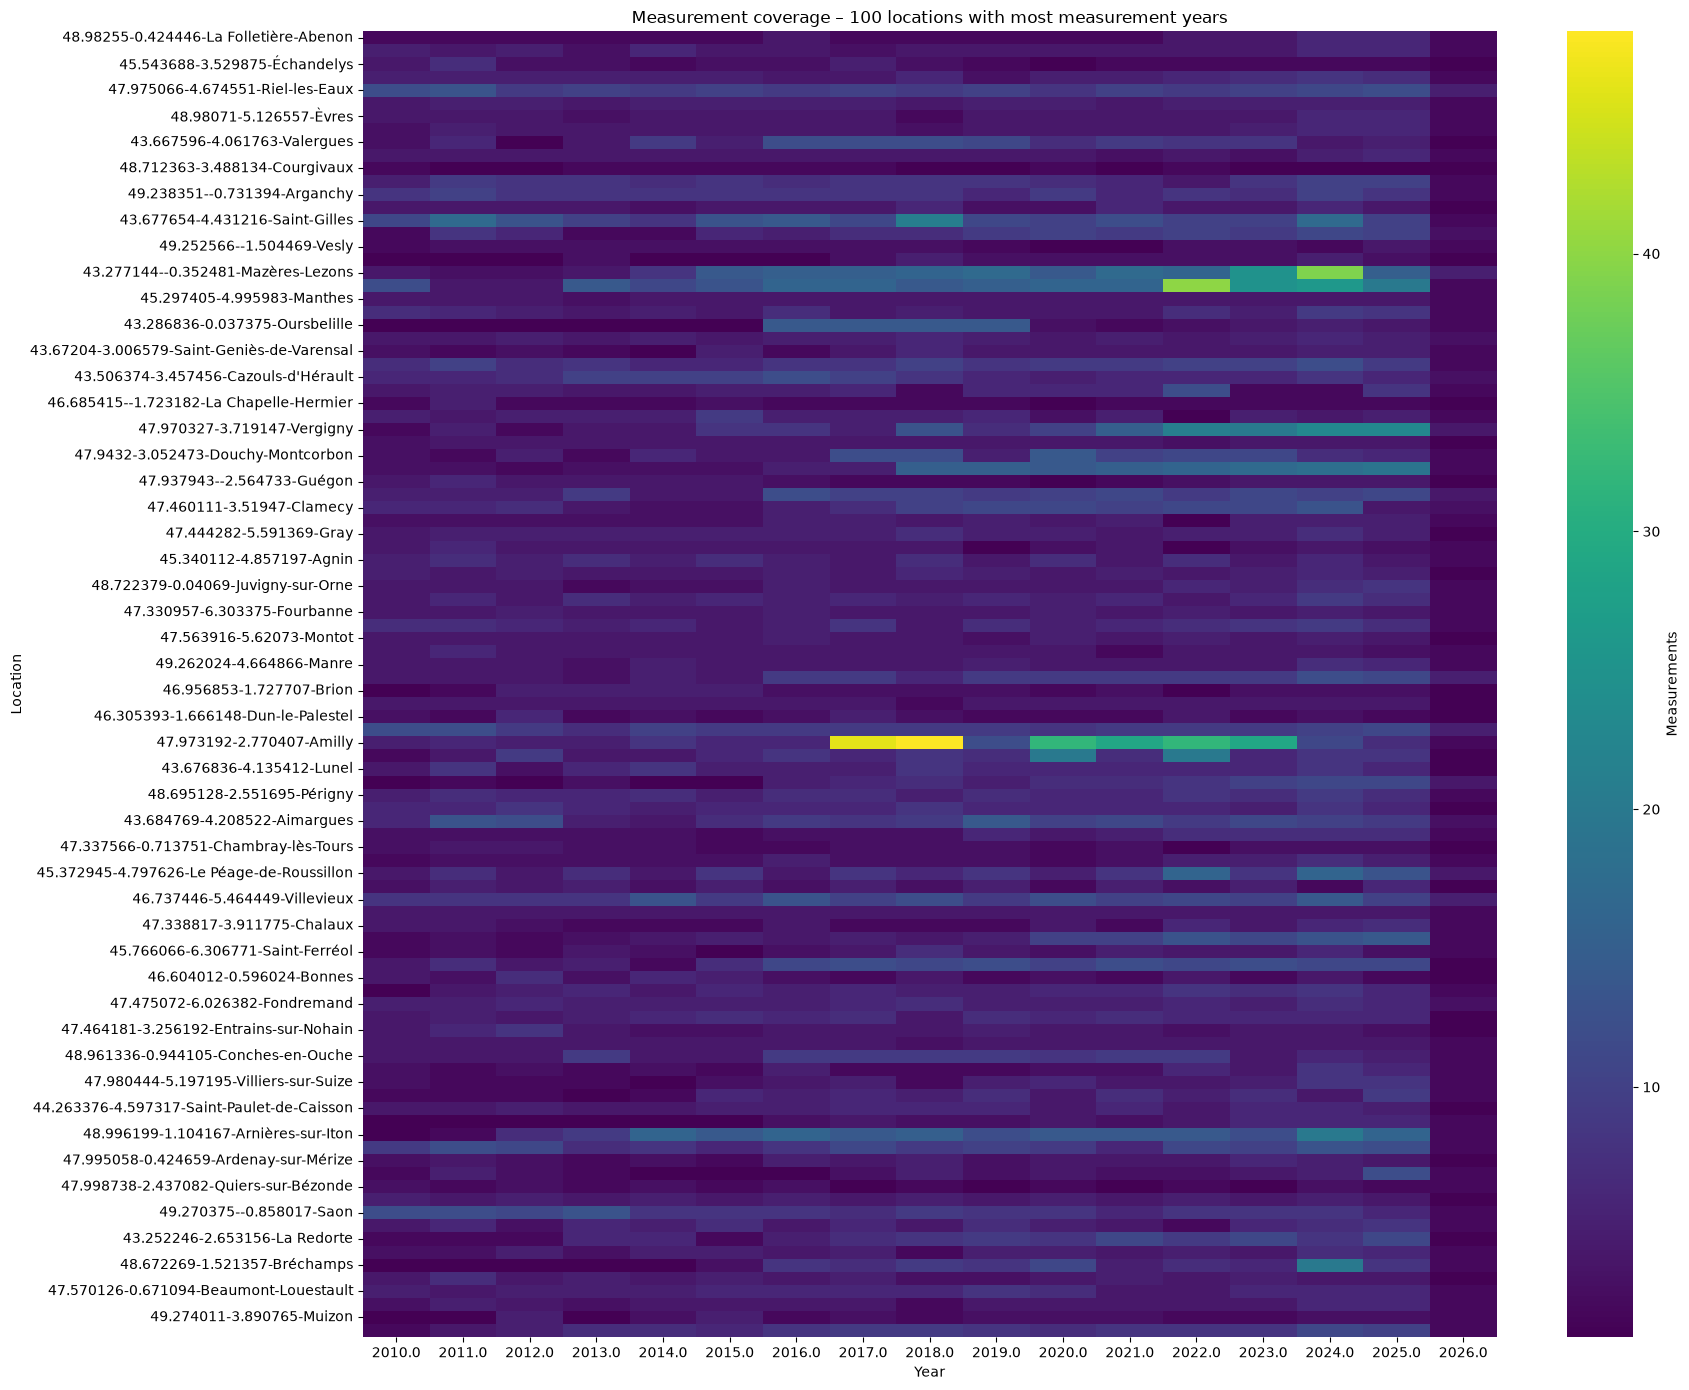

In [11]:
location_columns = ["lat", "lon", "city"]

# Number of years with measurements per location
years_per_location = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby(location_columns)["year"]
    .nunique()
)

# Measurements per location and year
measurements_location_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby([*location_columns, "year"])
    .size()
    .rename("measurement_count")
    .reset_index()
)

# Create heatmap
measurement_heatmap = (
    measurements_location_year
    .pivot(
        index=location_columns,
        columns="year",
        values="measurement_count",
    )
    .fillna(0)
)

# Sort locations by number of measurement years
location_order = (
    years_per_location
    .sort_values(ascending=False)
    .index
)

measurement_heatmap_sorted = measurement_heatmap.loc[
    location_order
]

# Show top 100 locations
measurement_heatmap_top = measurement_heatmap_sorted.head(100)

plt.figure(figsize=(18, 14))

sns.heatmap(
    measurement_heatmap_top,
    cmap="viridis",
    cbar_kws={"label": "Measurements"},
)

plt.title(
    "Measurement coverage – 100 locations with most measurement years"
)
plt.xlabel("Year")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

## How much overlap is there between locations?

## Conclusion
- We do need the other categories without any pfas-values or pfas-sums